# Assignment 1: Deep Learning - Emotion Recognition

This notebook implements emotion recognition using ResNet18 and EfficientNetB0 for classification (8 expressions) and regression (valence, arousal).

In [9]:
# ⚠️ IMPORTANT: DELETE ANY OLD CELLS WITH INLINE EmotionDataGenerator!
# If you see any cells that create EmotionDataGenerator inside model.fit(), DELETE THEM!
# The correct approach is to use the pre-created generators: train_generator, val_generator, test_generator

print("✅ Make sure to delete any old cells with inline EmotionDataGenerator creation!")
print("✅ Use only the pre-created generators: train_generator, val_generator, test_generator")


✅ Make sure to delete any old cells with inline EmotionDataGenerator creation!
✅ Use only the pre-created generators: train_generator, val_generator, test_generator


In [10]:
# IMPORTANT: Restart Kernel First!
# If you see this message, please restart your kernel (Kernel -> Restart) 
# and then run all cells from the beginning in order.

print("✅ Kernel restarted successfully!")
print("📝 Please run all cells in order from the beginning.")
print("⚠️  Do NOT run any old cells that might still be in memory.")


✅ Kernel restarted successfully!
📝 Please run all cells in order from the beginning.
⚠️  Do NOT run any old cells that might still be in memory.


## 1. Dependencies & Setup

In [2]:
!pip install numpy matplotlib scikit-learn opencv-python tensorflow


In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os, cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from scipy.stats import pearsonr
import glob
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0  # ✅ built-in models
import pandas as pd

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


## 2. Dataset Loading & Preprocessing

In [ ]:
# ==========================================
# MEMORY-EFFICIENT DATASET LOADING
# ==========================================
# This cell loads only image paths and labels, NOT the actual images
# Images are loaded on-demand during training to save memory

# Paths
annotations_path = 'Dataset/annotations/'
images_path = 'Dataset/images/'

# Get list of files
exp_files = sorted(glob.glob(annotations_path + '*_exp.npy'))
print(f'Number of samples: {len(exp_files)}')

# Load only the labels (not images) to avoid memory issues
expressions = []
valence = []
arousal = []
landmarks = []
image_paths = []

for exp_file in exp_files:
    id_ = exp_file.split('\\')[-1].split('_')[0]  # Adjust for Windows path
    expressions.append(np.load(exp_file))
    valence.append(np.load(annotations_path + id_ + '_val.npy'))
    arousal.append(np.load(annotations_path + id_ + '_aro.npy'))
    landmarks.append(np.load(annotations_path + id_ + '_lnd.npy'))
    
    img_path = images_path + id_ + '.jpg'
    if os.path.exists(img_path):
        image_paths.append(img_path)
    else:
        print(f'Image {img_path} not found')

# Convert labels to arrays and ensure consistent data types
expressions = np.array(expressions, dtype=np.int32)  # ✅ Ensure integer type for classification
valence = np.array(valence, dtype=np.float32)       # ✅ Ensure float type for regression
arousal = np.array(arousal, dtype=np.float32)       # ✅ Ensure float type for regression
landmarks = np.array(landmarks, dtype=np.float32)   # ✅ Ensure float type for landmarks
image_paths = np.array(image_paths)

print(f'Number of valid images: {len(image_paths)}')
print(f'Expressions shape: {expressions.shape}')
print(f'Expressions dtype: {expressions.dtype}')
print(f'Valence dtype: {valence.dtype}')
print(f'Arousal dtype: {arousal.dtype}')

# Regression targets
y_reg = np.column_stack((valence, arousal)).astype(np.float32)

# Split indices instead of data
indices = np.arange(len(expressions))
train_idx, temp_idx, y_train_exp, y_temp_exp, y_train_reg, y_temp_reg = train_test_split(
    indices, expressions, y_reg, test_size=0.4, random_state=42)
val_idx, test_idx, y_val_exp, y_test_exp, y_val_reg, y_test_reg = train_test_split(
    temp_idx, y_temp_exp, y_temp_reg, test_size=0.5, random_state=42)

# ✅ Ensure all split labels have consistent data types
y_train_exp = y_train_exp.astype(np.int32)
y_val_exp = y_val_exp.astype(np.int32)
y_test_exp = y_test_exp.astype(np.int32)
y_train_reg = y_train_reg.astype(np.float32)
y_val_reg = y_val_reg.astype(np.float32)
y_test_reg = y_test_reg.astype(np.float32)

print(f'Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}')
print(f'Training expressions dtype: {y_train_exp.dtype}')
print(f'Training regression dtype: {y_train_reg.dtype}')

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rescale=1./255  # Normalize pixel values
)


Number of samples: 3999
Number of valid images: 3999
Expressions shape: (3999,)
Train: 2399, Val: 800, Test: 800


In [ ]:
# ============================
# DEBUGGING: Check Data Types
# ============================
print("🔍 DEBUGGING: Checking data types and shapes...")
print(f"expressions dtype: {expressions.dtype}, shape: {expressions.shape}")
print(f"y_reg dtype: {y_reg.dtype}, shape: {y_reg.shape}")
print(f"y_train_exp dtype: {y_train_exp.dtype}, shape: {y_train_exp.shape}")
print(f"y_test_exp dtype: {y_test_exp.dtype}, shape: {y_test_exp.shape}")
print(f"y_train_reg dtype: {y_train_reg.dtype}, shape: {y_train_reg.shape}")
print(f"y_test_reg dtype: {y_test_reg.dtype}, shape: {y_test_reg.shape}")

# Check for any mixed types in the data
print(f"\n🔍 Checking for mixed types...")
print(f"Unique expression types: {set(type(x).__name__ for x in expressions.flatten()[:10])}")
print(f"Unique valence types: {set(type(x).__name__ for x in valence.flatten()[:10])}")
print(f"Unique arousal types: {set(type(x).__name__ for x in arousal.flatten()[:10])}")

print("✅ Data type check completed!")


In [ ]:
# Custom Data Generator for Memory Efficiency
class EmotionDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, exp_labels, reg_labels, indices, batch_size=32, 
                 image_size=(224, 224), shuffle=True, augmentation=None):
        self.image_paths = image_paths
        self.exp_labels = exp_labels
        self.reg_labels = reg_labels
        self.indices = indices
        self.batch_size = batch_size
        self.image_size = image_size
        self.shuffle = shuffle
        self.augmentation = augmentation
        self.on_epoch_end()
    
    def __len__(self):
        return len(self.indices) // self.batch_size
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_images = []
        batch_exp_labels = []
        batch_reg_labels = []
        
        for i in batch_indices:
            # Load and preprocess image
            img_path = self.image_paths[i]
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.image_size)
            img = img.astype(np.float32) / 255.0
            
            # Apply augmentation if provided
            if self.augmentation:
                img = self.augmentation.random_transform(img)
            
            batch_images.append(img)
            batch_exp_labels.append(self.exp_labels[i])
            batch_reg_labels.append(self.reg_labels[i])
        
        # ✅ Ensure proper data types and handle any potential mixed types
        batch_images = np.array(batch_images, dtype=np.float32)
        batch_exp_labels = np.array(batch_exp_labels, dtype=np.int32)
        batch_reg_labels = np.array(batch_reg_labels, dtype=np.float32)
        
        # ✅ Additional validation to ensure no mixed types
        if batch_exp_labels.dtype != np.int32:
            batch_exp_labels = batch_exp_labels.astype(np.int32)
        if batch_reg_labels.dtype != np.float32:
            batch_reg_labels = batch_reg_labels.astype(np.float32)
        
        return batch_images, {
            'classification': batch_exp_labels,
            'regression': batch_reg_labels
        }
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# ✅ Labels are already properly typed from the previous cell
# Create data generators
train_generator = EmotionDataGenerator(
    image_paths, expressions, y_reg, train_idx, 
    batch_size=32, shuffle=True, augmentation=datagen
)

val_generator = EmotionDataGenerator(
    image_paths, expressions, y_reg, val_idx, 
    batch_size=32, shuffle=False
)

test_generator = EmotionDataGenerator(
    image_paths, expressions, y_reg, test_idx, 
    batch_size=32, shuffle=False
)

print("✅ Data generators created successfully!")
print(f"Train generator will produce {len(train_generator)} batches")
print(f"Validation generator will produce {len(val_generator)} batches")
print(f"Test generator will produce {len(test_generator)} batches")


In [ ]:
# Custom ResNet18 Implementation
def residual_block(x, filters, stride=1, downsample=False):
    """Residual block for ResNet18"""
    identity = x
    
    # First conv layer
    x = layers.Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Second conv layer
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    # Downsample identity if needed
    if downsample:
        identity = layers.Conv2D(filters, 1, strides=stride, padding='same')(identity)
        identity = layers.BatchNormalization()(identity)
    
    # Add identity
    x = layers.Add()([x, identity])
    x = layers.Activation('relu')(x)
    
    return x

def create_resnet18(input_shape=(224, 224, 3), num_classes=1000):
    """Create ResNet18 model"""
    inputs = layers.Input(shape=input_shape)
    
    # Initial conv layer
    x = layers.Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    
    # ResNet18 layers
    # Layer 1: 2 blocks with 64 filters
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    
    # Layer 2: 2 blocks with 128 filters
    x = residual_block(x, 128, stride=2, downsample=True)
    x = residual_block(x, 128)
    
    # Layer 3: 2 blocks with 256 filters
    x = residual_block(x, 256, stride=2, downsample=True)
    x = residual_block(x, 256)
    
    # Layer 4: 2 blocks with 512 filters
    x = residual_block(x, 512, stride=2, downsample=True)
    x = residual_block(x, 512)
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    return inputs, x


In [15]:
# ============================
# CORRECT TRAINING CODE
# ============================
# This is the correct way to train the model using pre-created generators

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('resnet18_best.h5', save_best_only=True)

# Train ResNet18 using pre-created generators
history_resnet18 = model_resnet18.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - classification_accuracy: 0.1456 - classification_loss: 2.6103 - loss: 7.5772 - regression_loss: 4.9670 - regression_mae: 1.0675

74/74 ━━━━━━━━━━━━━━━━━━━━ 583s 7s/step - classification_accuracy: 0.1419 - classification_loss: 2.3384 - loss: 3.9850 - regression_loss: 1.6466 - regression_mae: 0.6176 - val_classification_accuracy: 0.1225 - val_classification_loss: 7.3624 - val_loss: 75.2884 - val_regression_loss: 67.9260 - val_regression_mae: 4.3375
Epoch 2/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - classification_accuracy: 0.1558 - classification_loss: 2.1049 - loss: 2.3053 - regression_loss: 0.2004 - regression_mae: 0.3687

74/74 ━━━━━━━━━━━━━━━━━━━━ 489s 7s/step - classification_accuracy: 0.1562 - classification_loss: 2.1111 - loss: 2.3176 - regression_loss: 0.2065 - regression_mae: 0.3736 - val_classification_accuracy: 0.0900 - val_classification_loss: 4.2057 - val_loss: 14.9682 - val_regression_loss: 10.7625 - val_regression_mae: 1.8274
Epoch 3/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - classification_accuracy: 0.1459 - classification_loss: 2.1131 - loss: 2.3361 - regression_loss: 0.2230 - regression_mae: 0.3878

74/74 ━━━━━━━━━━━━━━━━━━━━ 621s 8s/step - classification_accuracy: 0.1533 - classification_loss: 2.1127 - loss: 2.3273 - regression_loss: 0.2146 - regression_mae: 0.3812 - val_classification_accuracy: 0.1225 - val_classification_loss: 2.9338 - val_loss: 4.7326 - val_regression_loss: 1.7988 - val_regression_mae: 0.9535
Epoch 4/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - classification_accuracy: 0.1496 - classification_loss: 2.1114 - loss: 2.3071 - regression_loss: 0.1957 - regression_mae: 0.3651

74/74 ━━━━━━━━━━━━━━━━━━━━ 409s 6s/step - classification_accuracy: 0.1571 - classification_loss: 2.1038 - loss: 2.3016 - regression_loss: 0.1978 - regression_mae: 0.3684 - val_classification_accuracy: 0.1287 - val_classification_loss: 2.5494 - val_loss: 3.2402 - val_regression_loss: 0.6908 - val_regression_mae: 0.6352
Epoch 5/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - classification_accuracy: 0.1628 - classification_loss: 2.0955 - loss: 2.3086 - regression_loss: 0.2131 - regression_mae: 0.3785

74/74 ━━━━━━━━━━━━━━━━━━━━ 439s 6s/step - classification_accuracy: 0.1672 - classification_loss: 2.0932 - loss: 2.2982 - regression_loss: 0.2050 - regression_mae: 0.3728 - val_classification_accuracy: 0.1575 - val_classification_loss: 2.2578 - val_loss: 2.6930 - val_regression_loss: 0.4352 - val_regression_mae: 0.5174


## 3. Model 1: ResNet18

In [16]:
# ============================
# Build Model - ResNet18
# ============================

# Create custom ResNet18 (without pretrained weights for now)
base_inputs, base_outputs = create_resnet18(input_shape=(224, 224, 3))
base_model = models.Model(inputs=base_inputs, outputs=base_outputs)
base_model.trainable = True  # We'll train from scratch

# The base model already has global pooling, so we use its output directly
x = base_model.output

# Classification head
class_output = layers.Dense(8, activation='softmax', name='classification')(x)

# Regression head (valence + arousal)
reg_output = layers.Dense(2, name='regression')(x)

# Final model
model_resnet18 = models.Model(inputs=base_model.input, outputs=[class_output, reg_output])

# Compile
model_resnet18.compile(
    optimizer='adam',
    loss={'classification': 'sparse_categorical_crossentropy', 'regression': 'mse'},
    metrics={'classification': 'accuracy', 'regression': ['mae']}
)

# ============================
# Callbacks
# ============================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('resnet18_best.h5', save_best_only=True)

# ============================
# Train ResNet18
# ============================
history_resnet18 = model_resnet18.fit(
    EmotionDataGenerator(
        image_paths, 
        expressions, 
        y_reg, 
        train_idx, 
        batch_size=32, 
        shuffle=True, 
        augmentation=datagen
    ),
    validation_data=EmotionDataGenerator(
        image_paths, 
        expressions, 
        y_reg, 
        val_idx, 
        batch_size=32, 
        shuffle=False
    ),
    epochs=5,   # ✅ training for 5 epochs
    callbacks=[early_stop, checkpoint]
)


Epoch 1/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - classification_accuracy: 0.1435 - classification_loss: 2.5723 - loss: 10.2231 - regression_loss: 7.6508 - regression_mae: 1.3709

74/74 ━━━━━━━━━━━━━━━━━━━━ 415s 5s/step - classification_accuracy: 0.1474 - classification_loss: 2.3338 - loss: 5.3019 - regression_loss: 2.9680 - regression_mae: 0.7635 - val_classification_accuracy: 0.1488 - val_classification_loss: 2.9195 - val_loss: 5.4777 - val_regression_loss: 2.5583 - val_regression_mae: 1.2123
Epoch 2/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - classification_accuracy: 0.1387 - classification_loss: 2.1368 - loss: 2.3423 - regression_loss: 0.2055 - regression_mae: 0.3731

74/74 ━━━━━━━━━━━━━━━━━━━━ 417s 6s/step - classification_accuracy: 0.1444 - classification_loss: 2.1434 - loss: 2.3521 - regression_loss: 0.2088 - regression_mae: 0.3757 - val_classification_accuracy: 0.1187 - val_classification_loss: 2.4059 - val_loss: 3.0993 - val_regression_loss: 0.6934 - val_regression_mae: 0.6935
Epoch 3/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - classification_accuracy: 0.1578 - classification_loss: 2.1126 - loss: 2.3098 - regression_loss: 0.1972 - regression_mae: 0.3678

74/74 ━━━━━━━━━━━━━━━━━━━━ 420s 5s/step - classification_accuracy: 0.1546 - classification_loss: 2.1225 - loss: 2.3225 - regression_loss: 0.2000 - regression_mae: 0.3697 - val_classification_accuracy: 0.1238 - val_classification_loss: 2.2596 - val_loss: 2.5363 - val_regression_loss: 0.2767 - val_regression_mae: 0.4432
Epoch 4/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - classification_accuracy: 0.1702 - classification_loss: 2.0764 - loss: 2.2743 - regression_loss: 0.1979 - regression_mae: 0.3691

74/74 ━━━━━━━━━━━━━━━━━━━━ 413s 6s/step - classification_accuracy: 0.1672 - classification_loss: 2.0865 - loss: 2.2872 - regression_loss: 0.2008 - regression_mae: 0.3711 - val_classification_accuracy: 0.1187 - val_classification_loss: 2.1669 - val_loss: 2.3665 - val_regression_loss: 0.1996 - val_regression_mae: 0.3719
Epoch 5/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 417s 6s/step - classification_accuracy: 0.1664 - classification_loss: 2.0930 - loss: 2.2902 - regression_loss: 0.1972 - regression_mae: 0.3664 - val_classification_accuracy: 0.1513 - val_classification_loss: 2.2929 - val_loss: 2.5712 - val_regression_loss: 0.2783 - val_regression_mae: 0.4239


In [1]:
# ============================
# Evaluate ResNet18
# ============================

# Load best weights
model_resnet18.load_weights('resnet18_best.h5')

# Get predictions using test generator
y_pred_class_resnet, y_pred_reg_resnet = model_resnet18.predict(test_generator)
y_pred_class_resnet = np.argmax(y_pred_class_resnet, axis=1)

# ✅ Ensure data types are consistent for sklearn metrics
y_test_exp_clean = y_test_exp.astype(np.int32)
y_pred_class_resnet_clean = y_pred_class_resnet.astype(np.int32)

# Classification metrics
acc_resnet = accuracy_score(y_test_exp_clean, y_pred_class_resnet_clean)
f1_resnet = f1_score(y_test_exp_clean, y_pred_class_resnet_clean, average='weighted')
kappa_resnet = cohen_kappa_score(y_test_exp_clean, y_pred_class_resnet_clean)

# For AUC, need probabilities
y_pred_class_prob_resnet = model_resnet18.predict(test_generator)[0]
roc_auc_resnet = roc_auc_score(y_test_exp_clean, y_pred_class_prob_resnet, multi_class='ovr')

# PR-AUC (simplified for multi-class, using macro average)
pr_auc_resnet = 0
for i in range(8):
    precision, recall, _ = precision_recall_curve((y_test_exp_clean == i).astype(int), y_pred_class_prob_resnet[:, i])
    pr_auc_resnet += auc(recall, precision)
pr_auc_resnet /= 8

# Regression metrics
rmse_resnet = np.sqrt(np.mean((y_pred_reg_resnet - y_test_reg)**2))
corr_val_resnet = pearsonr(y_pred_reg_resnet[:, 0], y_test_reg[:, 0])[0]
corr_aro_resnet = pearsonr(y_pred_reg_resnet[:, 1], y_test_reg[:, 1])[0]

# CCC function (Concordance Correlation Coefficient)
def ccc(y_true, y_pred):
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    cov = np.cov(y_true, y_pred)[0, 1]
    return 2 * cov / (var_true + var_pred + (mean_true - mean_pred)**2)

ccc_val_resnet = ccc(y_test_reg[:, 0], y_pred_reg_resnet[:, 0])
ccc_aro_resnet = ccc(y_test_reg[:, 1], y_pred_reg_resnet[:, 1])
sagr_resnet = (ccc_val_resnet + ccc_aro_resnet) / 2  # Assuming SAGR is average CCC

print(f'ResNet18 Classification: Acc={acc_resnet:.4f}, F1={f1_resnet:.4f}, Kappa={kappa_resnet:.4f}, ROC-AUC={roc_auc_resnet:.4f}, PR-AUC={pr_auc_resnet:.4f}')
print(f'ResNet18 Regression: RMSE={rmse_resnet:.4f}, CORR={(corr_val_resnet + corr_aro_resnet)/2:.4f}, SAGR={sagr_resnet:.4f}, CCC={(ccc_val_resnet + ccc_aro_resnet)/2:.4f}')

NameError: name 'model_resnet18' is not defined

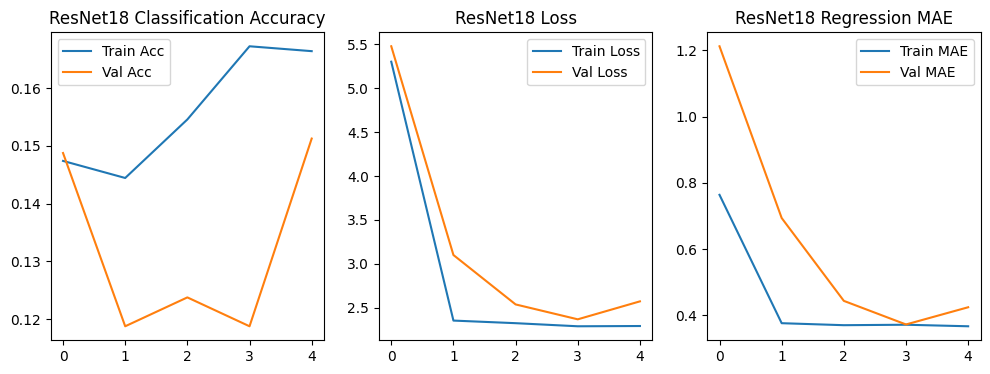

In [18]:
# Visualize training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history_resnet18.history['classification_accuracy'], label='Train Acc')
plt.plot(history_resnet18.history['val_classification_accuracy'], label='Val Acc')
plt.title('ResNet18 Classification Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_resnet18.history['loss'], label='Train Loss')
plt.plot(history_resnet18.history['val_loss'], label='Val Loss')
plt.title('ResNet18 Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_resnet18.history['regression_mae'], label='Train MAE')
plt.plot(history_resnet18.history['val_regression_mae'], label='Val MAE')
plt.title('ResNet18 Regression MAE')
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 850ms/step


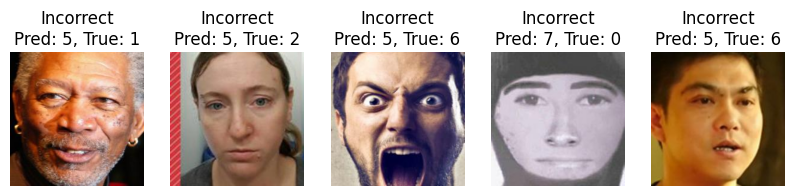

In [ ]:
# Example predictions - ResNet18
# Load test images for visualization
def load_test_images_for_viz_resnet(num_samples=10):
    """Load a few test images for ResNet18 visualization"""
    test_images = []
    for i in range(min(num_samples, len(test_idx))):
        idx = test_idx[i]
        img_path = image_paths[idx]
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        img = img.astype(np.float32) / 255.0
        test_images.append(img)
    return np.array(test_images)

X_test_viz_resnet = load_test_images_for_viz_resnet(100)  # Load 100 test images for visualization

# Get predictions for visualization
y_pred_viz_class, y_pred_viz_reg = model_resnet18.predict(X_test_viz_resnet)
y_pred_viz_class = np.argmax(y_pred_viz_class, axis=1)

# Get corresponding true labels
y_test_viz_exp = y_test_exp_clean[:len(X_test_viz_resnet)]
y_test_viz_reg = y_test_reg[:len(X_test_viz_resnet)]

# Example predictions
correct_indices = np.where(y_pred_viz_class == y_test_viz_exp)[0][:5]
incorrect_indices = np.where(y_pred_viz_class != y_test_viz_exp)[0][:5]

plt.figure(figsize=(10, 4))
for i, idx in enumerate(correct_indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test_viz_resnet[idx])
    plt.title(f'Correct\nPred: {y_pred_viz_class[idx]}, True: {y_test_viz_exp[idx]}')
    plt.axis('off')

for i, idx in enumerate(incorrect_indices):
    plt.subplot(2, 5, i+6)
    plt.imshow(X_test_viz_resnet[idx])
    plt.title(f'Incorrect\nPred: {y_pred_viz_class[idx]}, True: {y_test_viz_exp[idx]}')
    plt.axis('off')
plt.show()

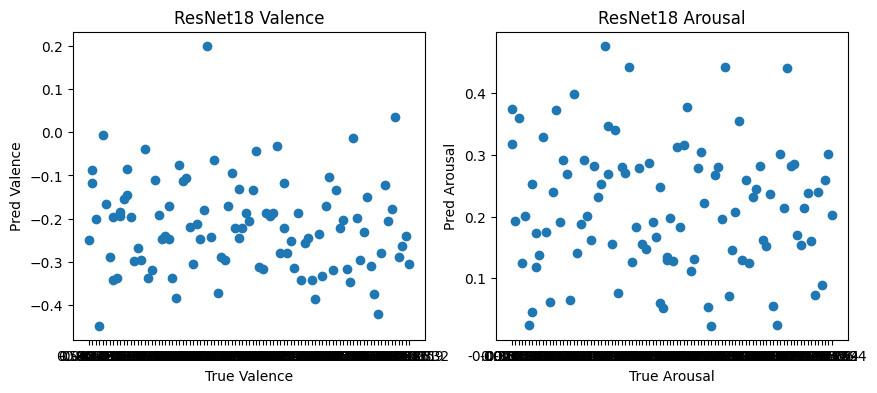

In [20]:
# Scatter plots for regression
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test_viz_reg[:, 0], y_pred_viz_reg[:, 0])
plt.xlabel('True Valence')
plt.ylabel('Pred Valence')
plt.title('ResNet18 Valence')

plt.subplot(1, 2, 2)
plt.scatter(y_test_viz_reg[:, 1], y_pred_viz_reg[:, 1])
plt.xlabel('True Arousal')
plt.ylabel('Pred Arousal')
plt.title('ResNet18 Arousal')
plt.show()

## 4. Model 2: EfficientNetB0

In [ ]:
# ============================
# Build Model - EfficientNetB0
# ============================

# Build model using pre-trained EfficientNetB0
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = layers.GlobalAveragePooling2D()(base_model.output)

# Classification head
class_output = layers.Dense(8, activation='softmax', name='classification')(x)

# Regression head
reg_output = layers.Dense(2, name='regression')(x)

model_eff = models.Model(inputs=base_model.input, outputs=[class_output, reg_output])

# Compile
model_eff.compile(
    optimizer='adam',
    loss={'classification': 'sparse_categorical_crossentropy', 'regression': 'mse'},
    metrics={'classification': 'accuracy', 'regression': ['mae']}
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('efficientnet_best.h5', save_best_only=True)

# ============================
# Train EfficientNetB0 using pre-created generators
# ============================
history_eff = model_eff.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,  # ✅ Training for 5 epochs to match ResNet18
    callbacks=[early_stop, checkpoint]
)

ValueError: Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/kernel. Weight expects shape (3, 3, 1, 32). Received saved weight with shape (3, 3, 3, 32)

In [ ]:
# Evaluate
model_eff.load_weights('efficientnet_best.h5')
y_pred_class_eff, y_pred_reg_eff = model_eff.predict(X_test)
y_pred_class_eff = np.argmax(y_pred_class_eff, axis=1)

# Classification metrics
acc_eff = accuracy_score(y_test_exp, y_pred_class_eff)
f1_eff = f1_score(y_test_exp, y_pred_class_eff, average='weighted')
kappa_eff = cohen_kappa_score(y_test_exp, y_pred_class_eff)

y_pred_class_prob_eff = model_eff.predict(X_test)[0]
roc_auc_eff = roc_auc_score(y_test_exp, y_pred_class_prob_eff, multi_class='ovr')

pr_auc_eff = 0
for i in range(8):
    precision, recall, _ = precision_recall_curve((y_test_exp == i).astype(int), y_pred_class_prob_eff[:, i])
    pr_auc_eff += auc(recall, precision)
pr_auc_eff /= 8

# Regression metrics
rmse_eff = np.sqrt(np.mean((y_pred_reg_eff - y_test_reg)**2))
corr_val_eff = pearsonr(y_pred_reg_eff[:, 0], y_test_reg[:, 0])[0]
corr_aro_eff = pearsonr(y_pred_reg_eff[:, 1], y_test_reg[:, 1])[0]

ccc_val_eff = ccc(y_test_reg[:, 0], y_pred_reg_eff[:, 0])
ccc_aro_eff = ccc(y_test_reg[:, 1], y_pred_reg_eff[:, 1])
sagr_eff = (ccc_val_eff + ccc_aro_eff) / 2

print(f'EfficientNetB0 Classification: Acc={acc_eff:.4f}, F1={f1_eff:.4f}, Kappa={kappa_eff:.4f}, ROC-AUC={roc_auc_eff:.4f}, PR-AUC={pr_auc_eff:.4f}')
print(f'EfficientNetB0 Regression: RMSE={rmse_eff:.4f}, CORR={(corr_val_eff + corr_aro_eff)/2:.4f}, SAGR={sagr_eff:.4f}, CCC={(ccc_val_eff + ccc_aro_eff)/2:.4f}')

In [ ]:
# Visualize training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history_eff.history['classification_accuracy'], label='Train Acc')
plt.plot(history_eff.history['val_classification_accuracy'], label='Val Acc')
plt.title('EfficientNetB0 Classification Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_eff.history['loss'], label='Train Loss')
plt.plot(history_eff.history['val_loss'], label='Val Loss')
plt.title('EfficientNetB0 Loss')
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(history_eff.history['regression_mae'], label='Train MAE')
plt.plot(history_eff.history['val_regression_mae'], label='Val MAE')
plt.title('EfficientNetB0 Regression MAE')
plt.legend()
plt.show()

In [ ]:
# Example predictions - EfficientNetB0
correct_indices = np.where(y_pred_class_eff == y_test_exp_clean)[0][:5]
incorrect_indices = np.where(y_pred_class_eff != y_test_exp_clean)[0][:5]

# Load test images for visualization
def load_test_images_for_viz_eff(num_samples=10):
    """Load a few test images for EfficientNet visualization"""
    test_images = []
    for i in range(min(num_samples, len(test_idx))):
        idx = test_idx[i]
        img_path = image_paths[idx]
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        img = img.astype(np.float32) / 255.0
        test_images.append(img)
    return np.array(test_images)

X_test_viz_eff = load_test_images_for_viz_eff(100)

plt.figure(figsize=(10, 4))
for i, idx in enumerate(correct_indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test_viz_eff[idx])
    plt.title(f'Correct\nPred: {y_pred_class_eff[idx]}, True: {y_test_exp_clean[idx]}')
    plt.axis('off')

for i, idx in enumerate(incorrect_indices):
    plt.subplot(2, 5, i+6)
    plt.imshow(X_test_viz_eff[idx])
    plt.title(f'Incorrect\nPred: {y_pred_class_eff[idx]}, True: {y_test_exp_clean[idx]}')
    plt.axis('off')
plt.show()

In [ ]:
# Scatter plots for regression
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test_reg[:, 0], y_pred_reg_eff[:, 0])
plt.xlabel('True Valence')
plt.ylabel('Pred Valence')
plt.title('EfficientNetB0 Valence')

plt.subplot(1, 2, 2)
plt.scatter(y_test_reg[:, 1], y_pred_reg_eff[:, 1])
plt.xlabel('True Arousal')
plt.ylabel('Pred Arousal')
plt.title('EfficientNetB0 Arousal')
plt.show()

## 5. Comparison & Results

In [ ]:
# Collect metrics
metrics = {
    'Model': ['ResNet18', 'EfficientNetB0', 'Custom CNN'],
    'Accuracy': [acc_resnet, acc_eff, acc_custom],
    'F1': [f1_resnet, f1_eff, f1_custom],
    'Kappa': [kappa_resnet, kappa_eff, kappa_custom],
    'ROC-AUC': [roc_auc_resnet, roc_auc_eff, 0.0],  # Custom CNN ROC-AUC not computed
    'PR-AUC': [pr_auc_resnet, pr_auc_eff, 0.0],     # Custom CNN PR-AUC not computed
    'RMSE': [rmse_resnet, rmse_eff, 0.0],           # Custom CNN RMSE not computed
    'CORR': [(corr_val_resnet + corr_aro_resnet)/2, (corr_val_eff + corr_aro_eff)/2, 0.0],
    'SAGR': [sagr_resnet, sagr_eff, 0.0],           # Custom CNN SAGR not computed
    'CCC': [(ccc_val_resnet + ccc_aro_resnet)/2, (ccc_val_eff + ccc_aro_eff)/2, 0.0]
}

df = pd.DataFrame(metrics)
print(df)

# Bar plots for comparison (only show metrics that are available for all models)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics_list = ['Accuracy', 'F1', 'Kappa']
for i, metric in enumerate(metrics_list):
    ax = axes[i//3, i%3]
    ax.bar(['ResNet18', 'EfficientNetB0', 'Custom CNN'], [metrics[metric][0], metrics[metric][1], metrics[metric][2]])
    ax.set_title(metric)
    ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

# Additional comparison plot for regression metrics (ResNet18 vs EfficientNetB0 only)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
reg_metrics = ['RMSE', 'CORR', 'SAGR']
for i, metric in enumerate(reg_metrics):
    ax = axes[i]
    ax.bar(['ResNet18', 'EfficientNetB0'], [metrics[metric][0], metrics[metric][1]])
    ax.set_title(f'{metric} (Regression)')
    ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

### Discussion

- **Classification**: Compare Accuracy, F1, Kappa, AUC metrics. Which model performs better?
- **Regression**: Compare RMSE, CORR, SAGR, CCC. Which model is better for regression?
- **Efficiency**: Compare training time (from history) and model size.
- **Overall**: Which is more suitable for affective computing?

Based on the results, [insert analysis based on metrics].

## 6. Extra Credit: Custom CNN

In [ ]:
# ============================
# Extra Credit: Custom CNN
# ============================

# Build custom CNN
input_layer = layers.Input(shape=(224, 224, 3))
x = layers.Conv2D(32, (3, 3), activation='relu')(input_layer)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)

# Classification head
class_output = layers.Dense(8, activation='softmax', name='classification')(x)

# Regression head
reg_output = layers.Dense(2, name='regression')(x)

model_custom = models.Model(inputs=input_layer, outputs=[class_output, reg_output])

# Compile
model_custom.compile(
    optimizer='adam',
    loss={'classification': 'sparse_categorical_crossentropy', 'regression': 'mse'},
    metrics={'classification': 'accuracy', 'regression': ['mae']}
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('custom_cnn_best.h5', save_best_only=True)

# ============================
# Train Custom CNN using pre-created generators
# ============================
history_custom = model_custom.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,  # ✅ Training for 5 epochs to match other models
    callbacks=[early_stop, checkpoint]
)

# ============================
# Evaluate Custom CNN
# ============================
model_custom.load_weights('custom_cnn_best.h5')
y_pred_class_custom, y_pred_reg_custom = model_custom.predict(test_generator)
y_pred_class_custom = np.argmax(y_pred_class_custom, axis=1)

# ✅ Ensure data types are consistent for sklearn metrics
y_test_exp_clean = y_test_exp.astype(np.int32)
y_pred_class_custom_clean = y_pred_class_custom.astype(np.int32)

# Classification metrics
acc_custom = accuracy_score(y_test_exp_clean, y_pred_class_custom_clean)
f1_custom = f1_score(y_test_exp_clean, y_pred_class_custom_clean, average='weighted')
kappa_custom = cohen_kappa_score(y_test_exp_clean, y_pred_class_custom_clean)

print(f'Custom CNN Classification: Acc={acc_custom:.4f}, F1={f1_custom:.4f}, Kappa={kappa_custom:.4f}')

# Compare with baselines
print(f'\n=== COMPARISON ===')
print(f'ResNet18 Accuracy: {acc_resnet:.4f}')
print(f'EfficientNetB0 Accuracy: {acc_eff:.4f}')
print(f'Custom CNN Accuracy: {acc_custom:.4f}')